<a href="https://colab.research.google.com/github/Holanpasaribu12/UAS/blob/main/UTS_DL_Holan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Restaurant reviews.csv to Restaurant reviews.csv


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving Restaurant reviews.csv to Restaurant reviews (1).csv
Jumlah data: 9955

Distribusi Sentimen:
label
2    6764
1    2285
0     906
Name: count, dtype: int64


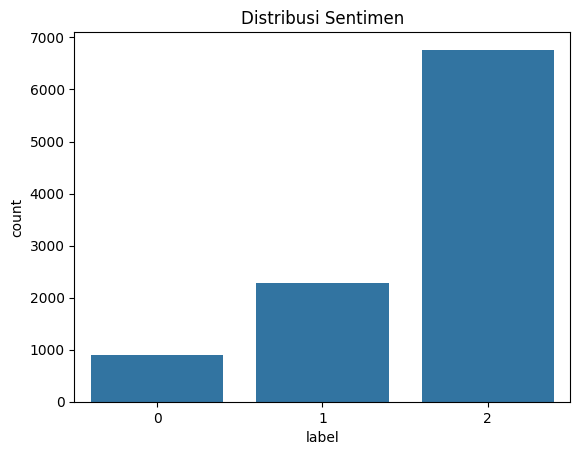

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 25s 92ms/step - accuracy: 0.7903 - loss: 0.6965 - val_accuracy: 0.9272 - val_loss: 0.2524
Epoch 2/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.9326 - loss: 0.2549 - val_accuracy: 0.9442 - val_loss: 0.1625
Epoch 3/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.9542 - loss: 0.1400 - val_accuracy: 0.9357 - val_loss: 0.1716
Epoch 4/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.9662 - loss: 0.1047 - val_accuracy: 0.9247 - val_loss: 0.2167
Epoch 5/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.9743 - loss: 0.0768 - val_accuracy: 0.9302 - val_loss: 0.2128
Epoch 6/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.9809 - loss: 0.0680 - val_accuracy: 0.9247 - val_loss: 0.2526
Epoch 7/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9859 - loss: 0.0398 - val_accuracy: 0.9232 - val_loss: 0.2890
Epoch 8/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.9901 - loss: 0.0346 - 

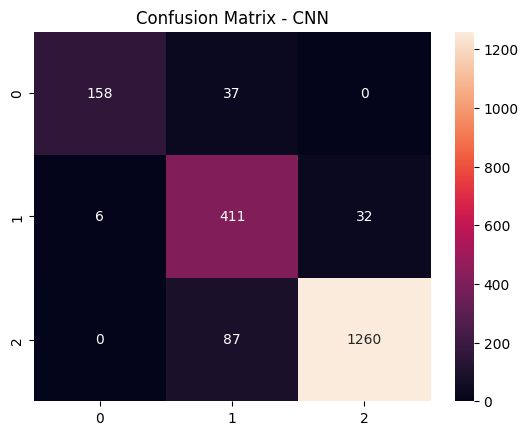


=== HASIL KEPUASAN (DATA TEST) ===
Puas: 1292
Tidak Puas: 164
Netral: 535

Contoh:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Puas


In [3]:
# ================================
# 1. INSTALL LIBRARY
# ================================
!pip install pandas numpy scikit-learn tensorflow nltk

# ================================
# 2. IMPORT LIBRARY
# ================================
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from google.colab import files

nltk.download('stopwords')
from nltk.corpus import stopwords

# ================================
# 3. UPLOAD DATA
# ================================
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

# ================================
# 4. CLEANING DATA
# ================================
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

if 'Review' in df.columns:
    df = df[['Review']]
elif 'review' in df.columns:
    df = df[['review']]
    df.columns = ['Review']

df = df[df['Review'].notna()]
print("Jumlah data:", len(df))

# ================================
# 5. PREPROCESSING TEXT
# ================================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_review'] = df['Review'].apply(clean_text)

# ================================
#  6. LABELING 
# ================================
positive_words = [
    'good','great','amazing','excellent','nice','love','delicious',
    'best','perfect','awesome','recommend','happy','fantastic','satisfied'
]

negative_words = [
    'bad','worst','awful','terrible','disappointed','poor','hate',
    'slow','dirty','boring','not good','not worth','bad service'
]

def sentiment_label(text):
    pos = sum([1 for w in positive_words if w in text])
    neg = sum([1 for w in negative_words if w in text])

    if pos > neg:
        return 2  # Puas
    elif neg > pos:
        return 0  # Tidak Puas
    else:
        return 1  # Netral

df['label'] = df['clean_review'].apply(sentiment_label)

# ================================
#  ANALISIS DATA
# ================================
print("\nDistribusi Sentimen:")
print(df['label'].value_counts())

sns.countplot(x=df['label'])
plt.title("Distribusi Sentimen")
plt.show()

# ================================
# 7. TOKENIZATION 
# ================================
max_words = 10000
max_len = 120

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_review'])

X = tokenizer.texts_to_sequences(df['clean_review'])
X = pad_sequences(X, maxlen=max_len)

y = np.array(df['label'])

# ================================
# 8. SPLIT DATA
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
#  HANDLE IMBALANCE 
# ================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weights = dict(enumerate(class_weights))

# ================================
# 9. MODEL CNN 
# ================================
model = Sequential()

model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

model.add(Conv1D(128, 5, activation='relu'))
model.add(Conv1D(64, 3, activation='relu'))

model.add(GlobalMaxPooling1D())

model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ================================
#  10. TRAINING 
# ================================
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

# ================================
# 11. EVALUATION
# ================================
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_classes))

cm = confusion_matrix(y_test, y_pred_classes)

print("\n=== Confusion Matrix ===")
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - CNN")
plt.show()

# ================================
# 12. HITUNG KEPUASAN
# ================================
puas = sum(y_pred_classes == 2)
tidak_puas = sum(y_pred_classes == 0)
netral = sum(y_pred_classes == 1)

print("\n=== HASIL KEPUASAN (DATA TEST) ===")
print("Puas:", puas)
print("Tidak Puas:", tidak_puas)
print("Netral:", netral)

# ================================
# 13. TEST MANUAL
# ================================
def predict_review(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len)
    pred = model.predict(pad)
    label = np.argmax(pred)

    if label == 0:
        return "Tidak Puas"
    elif label == 1:
        return "Netral"
    else:
        return "Puas"

print("\nContoh:")
print(predict_review("The food was amazing and service was excellent"))